In [84]:
import pandas as pd
import matplotlib.pyplot as plt

In [85]:
df = pd.read_csv("Time_series_analysis_and_forecast_DATASET.csv")
df.head()

,FullDate,Tmax,SysLoad,GasPrice,ElecPrice
0,2010-09-01 00:00:00,15.8,1688.215,3.69,23.710
1,2010-09-01 01:00:00,15.8,1669.195,3.69,22.635
2,2010-09-01 02:00:00,15.8,1491.980,3.69,22.565
3,2010-09-01 03:00:00,15.8,1330.760,3.69,18.910
4,2010-09-01 04:00:00,15.8,1247.940,3.69,18.030


In [86]:
df.shape

(92016, 5)

### Resample to day

In [87]:
# Must to converted to datetimeindex to enable resampling
df["FullDate"] = pd.to_datetime(df["FullDate"])
df.set_index("FullDate", inplace=True)

In [88]:
df = df.resample('D').sum()
df.head()

,Tmax,SysLoad,GasPrice,ElecPrice
FullDate,,,,
2010-09-01,379.2,41565.380,88.56,2751.700
2010-09-02,369.6,38898.990,88.56,570.810
2010-09-03,439.2,41665.760,106.80,504.975
2010-09-04,328.8,35638.085,81.36,502.275
2010-09-05,357.6,35611.410,106.80,500.555


In [89]:
# Reset the index back
df.reset_index(inplace=True)
df.head()

,FullDate,Tmax,SysLoad,GasPrice,ElecPrice
0,2010-09-01,379.2,41565.380,88.56,2751.700
1,2010-09-02,369.6,38898.990,88.56,570.810
2,2010-09-03,439.2,41665.760,106.80,504.975
3,2010-09-04,328.8,35638.085,81.36,502.275
4,2010-09-05,357.6,35611.410,106.80,500.555


In [90]:
df.shape

(3834, 5)

### Check for stationarity

In [91]:
from statsmodels.tsa.stattools import adfuller
adf_result = adfuller(df["ElecPrice"])

print(f'ADF Statistic: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')
print(f'No. of lags used: {adf_result[2]}')
print(f'No. of observations used : {adf_result[3]}')

ADF Statistic: -8.269053866873803
p-value: 4.848817773711633e-13
No. of lags used: 20
No. of observations used : 3813


Dataset is stationary and contains no missing values

### Univariant forecasting

In [92]:
from fbprophet import Prophet

In [93]:
df_univar = df[["FullDate", "ElecPrice"]].rename(columns={"FullDate":"ds", "ElecPrice":"y"})
df_univar.head()

,ds,y
0,2010-09-01,2751.700
1,2010-09-02,570.810
2,2010-09-03,504.975
3,2010-09-04,502.275
4,2010-09-05,500.555


#### Train Test split

In [94]:
df_train = df_univar.iloc[:2757]
df_test = df_univar.iloc[2757:]

assert df_univar.shape[0], df_train.shape[0] + df_test.shape[0]

print(df_train.shape)
print(df_test.shape)

(2757, 2)
(1077, 2)


In [95]:
model = Prophet()
model.fit(df_train)

INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [96]:
# Predict for the test set
future_dates = model.make_future_dataframe(periods= 1077 , freq= 'D')
forecast = model.predict(future_dates)

assert forecast.shape[0] == df_univar.shape[0]

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-09-01,851.777631,-1351.854087,3242.551658,851.777631,851.777631,144.250503,144.250503,144.250503,159.308129,159.308129,159.308129,-15.057627,-15.057627,-15.057627,0.0,0.0,0.0,996.028134
1,2010-09-02,851.727173,-1225.686179,3480.029832,851.727173,851.727173,224.453910,224.453910,224.453910,257.036327,257.036327,257.036327,-32.582418,-32.582418,-32.582418,0.0,0.0,0.0,1076.181083
2,2010-09-03,851.676716,-1501.917682,3275.461006,851.676716,851.676716,-0.584510,-0.584510,-0.584510,50.257478,50.257478,50.257478,-50.841988,-50.841988,-50.841988,0.0,0.0,0.0,851.092206
3,2010-09-04,851.626258,-1875.488853,2779.092319,851.626258,851.626258,-340.872526,-340.872526,-340.872526,-271.372061,-271.372061,-271.372061,-69.500465,-69.500465,-69.500465,0.0,0.0,0.0,510.753732
4,2010-09-05,851.575800,-1944.208040,2950.616390,851.575800,851.575800,-430.884955,-430.884955,-430.884955,-342.634443,-342.634443,-342.634443,-88.250512,-88.250512,-88.250512,0.0,0.0,0.0,420.690845


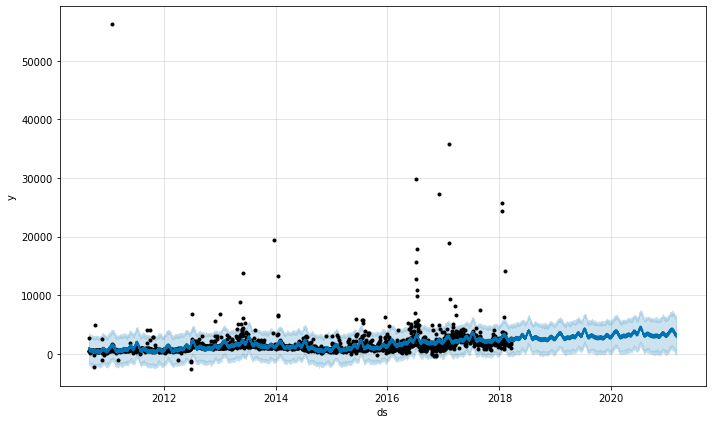

In [97]:
model.plot(forecast)
plt.show()

### Multivariant forcasting

In [98]:
df_multivar = df.rename(columns={"FullDate":"ds", "ElecPrice":"y", "SysLoad":"add1", "Tmax":"add2","GasPrice":"add3"})
df_multivar.head()

,ds,add2,add1,add3,y
0,2010-09-01,379.2,41565.380,88.56,2751.700
1,2010-09-02,369.6,38898.990,88.56,570.810
2,2010-09-03,439.2,41665.760,106.80,504.975
3,2010-09-04,328.8,35638.085,81.36,502.275
4,2010-09-05,357.6,35611.410,106.80,500.555


#### Train Test split

In [99]:
df_train_2 = df_multivar.iloc[:2757]
df_test_2 = df_multivar.iloc[2757:]

assert df_multivar.shape[0], df_train_2.shape[0] + df_test_2.shape[0]

print(df_train_2.shape)
print(df_test_2.shape)

(2757, 5)
(1077, 5)


In [100]:
model_2 = Prophet()

# Adding regressors
model_2.add_regressor("add1")
model_2.add_regressor("add2")
model_2.add_regressor("add3")

model_2.fit(df_train_2)

INFO:fbprophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [101]:
# Make future dates
future_dates_2 = model.make_future_dataframe(periods= 1077 , freq= 'D')
future_dates_2["add1"] = df_multivar["add1"]
future_dates_2["add2"] = df_multivar["add2"]
future_dates_2["add3"] = df_multivar["add3"]

future_dates_2.head()

,ds,add1,add2,add3
0,2010-09-01,41565.380,379.2,88.56
1,2010-09-02,38898.990,369.6,88.56
2,2010-09-03,41665.760,439.2,106.80
3,2010-09-04,35638.085,328.8,81.36
4,2010-09-05,35611.410,357.6,106.80


In [102]:
# Make predictions
forecast_2 = model_2.predict(future_dates_2)

forecast_2.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,add1,add1_lower,add1_upper,add2,...,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-09-01,999.344125,-687.590384,3733.112570,999.344125,999.344125,1036.684496,1036.684496,1036.684496,0.246552,...,42.497418,42.497418,42.497418,-4.148520,-4.148520,-4.148520,0.0,0.0,0.0,1517.026982
1,2010-09-02,999.900105,-669.962722,3838.944745,999.900105,999.900105,887.762012,887.762012,887.762012,0.247400,...,145.822951,145.822951,145.822951,-7.069370,-7.069370,-7.069370,0.0,0.0,0.0,1469.066011
2,2010-09-03,1000.456085,-605.650301,3952.249342,1000.456085,1000.456085,1042.290892,1042.290892,1042.290892,0.241251,...,-44.133439,-44.133439,-44.133439,-10.049485,-10.049485,-10.049485,0.0,0.0,0.0,1699.128738
3,2010-09-04,1001.012066,-1182.761594,3236.113496,1001.012066,1001.012066,705.634840,705.634840,705.634840,0.251004,...,-117.735502,-117.735502,-117.735502,-12.818541,-12.818541,-12.818541,0.0,0.0,0.0,912.988678
4,2010-09-05,1001.568046,-896.981240,3646.743594,1001.568046,1001.568046,704.144995,704.144995,704.144995,0.248460,...,-69.893610,-69.893610,-69.893610,-15.133453,-15.133453,-15.133453,0.0,0.0,0.0,1331.257873


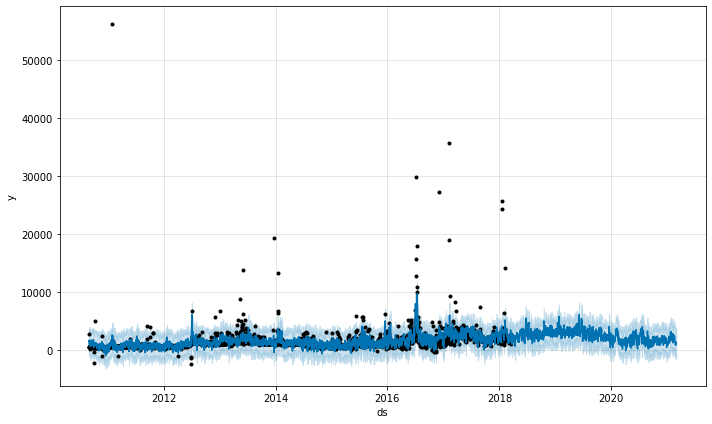

In [103]:
model_2.plot(forecast_2)
plt.show()

## Question 11

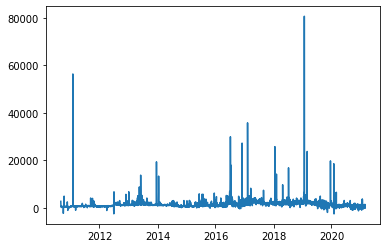

In [104]:
plt.plot(df["FullDate"], df["ElecPrice"])
plt.show()

## Question 12

In [105]:
from statsmodels.tsa.stattools import adfuller

def adf_p_value(column):

  adf_result = adfuller(column)
  p_value = round(adf_result[1], 6)
  print(f'p-value: {p_value}')

In [106]:
adf_p_value(df["SysLoad"])
adf_p_value(df["GasPrice"])

p-value: 0.004254
p-value: 0.045027


## Question 13

In [107]:
def adf_critical_val(column):

  adf_result = adfuller(column)
  
  for k, v in adf_result[4].items():
    print(f'{k}:{round(v, 4)}')

In [108]:
adf_critical_val(df["GasPrice"])
print('')
adf_critical_val(df["ElecPrice"])

1%:-3.4321
5%:-2.8623
10%:-2.5672

1%:-3.4321
5%:-2.8623
10%:-2.5672


In [109]:
from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = forecast[["yhat"]].iloc[2757:]
y_test = df_test["y"]

In [110]:
mape = np.mean(np.abs((y_test - y_pred)/y_test)*100)
print(np.mean(mape.index[:-1]))

3295.0


## Question 15

In [111]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(round(rmse, 2))

3218.16


## Question 16

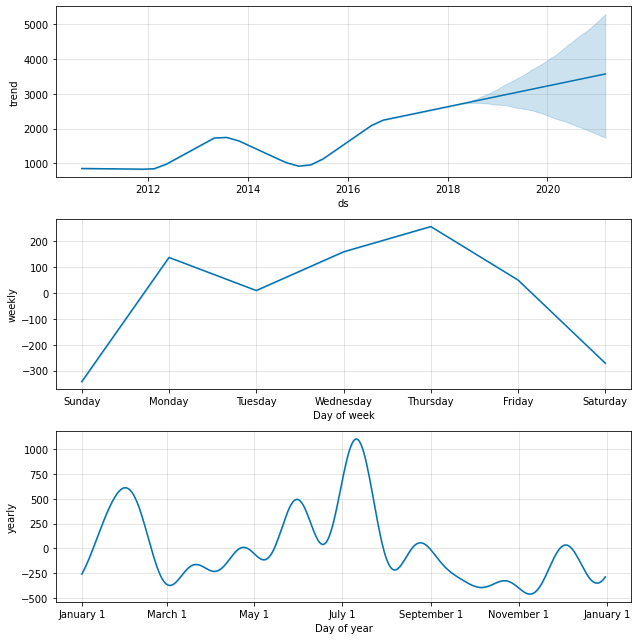

In [112]:
model.plot_components(forecast)
plt.show()

## Question 17

In [113]:
mape = np.mean(np.abs((y_test - y_pred)/y_test)*100)
print(np.mean(mape.index[:-1]))

3295.0


## Question 18

In [114]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(round(rmse, 2))

3218.16


## Question 19

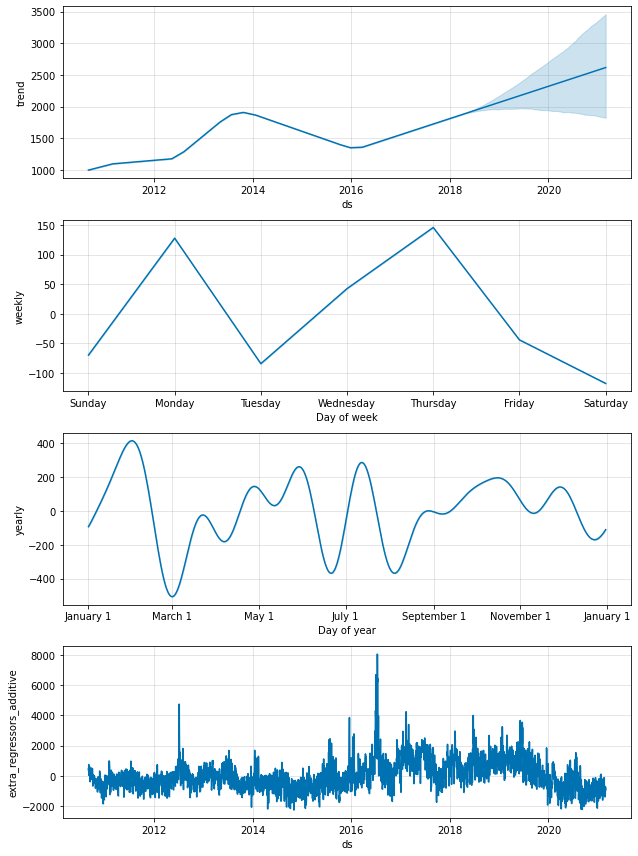

In [115]:
model_2.plot_components(forecast_2)
plt.show()